# ERC-4626: vault report for blog posts

- This is the same as [ERC-4626 best vaults](./erc4626-best-vaults.html) notebook, but tailored for the blog post output
- The output is condensed with less charts, lists and data points
- Tables are outputted as Markdown for copy-paste and the rendering is left to the blog engine
- Vaults are ranked by 1M returns unless noted otherwise

**Note**: The monthly blog report is now generated with `scripts/erc-4626/generate-monthly-vault-report.py`, see `eth_defi/vault_report/README-vault-report.md`. This notebook is kept for ad hoc research.

## Setup

- Set up notebook rendering output mode
- Use static image charts so this notebook is readeable on Github / ReadTheDocs

In [1]:
import pandas as pd
from plotly.offline import init_notebook_mode
import plotly.io as pio

from eth_defi.research.notebook import set_large_plotly_chart_font

pd.options.display.float_format = "{:,.2f}".format
pd.options.display.max_columns = None
pd.options.display.max_rows = None


# Set up Plotly chart output as SVG
image_format = "png"
width = 1400
height = 800

# https://stackoverflow.com/a/52956402/315168
init_notebook_mode()

# https://stackoverflow.com/a/74609837/315168
assert hasattr(pio, "kaleido"), "Kaleido rendering backend missing. Run 'pip install kaleido' needed for this notebook"
pio.kaleido.scope.default_format = image_format

# https://plotly.com/python/renderers/#overriding-the-default-renderer
pio.renderers.default = image_format

current_renderer = pio.renderers[image_format]
# Have SVGs default pixel with
current_renderer.width = width
current_renderer.height = height

# Set all Plotly charts to use large font sizes for better readability,
# for sharing on mobile
set_large_plotly_chart_font(line_width=5, legend_font_size=16)
pio.templates.default = "custom"

/var/folders/8n/h2dzh5yx5470cc6c_12dwrjw0000gn/T/ipykernel_58725/1747694510.py:22: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_format is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_format instead.




## Read previously scanned vault price data

- Read the Parquet file produced earlier with price scan 

In [2]:
from pathlib import Path
from eth_defi.vault.vaultdb import VaultDatabase, read_default_vault_prices
from eth_defi.research.vault_metrics import cross_check_data

output_folder = Path("~/.tradingstrategy/vaults").expanduser()
parquet_file = output_folder / "cleaned-vault-prices-1h.parquet"
assert parquet_file.exists(), "Run the vault scanner script first"

vault_db = VaultDatabase.read()
prices_df = read_default_vault_prices()

chains = prices_df["chain"].unique()

print(f"The report data is dated {prices_df.index.min()} - {prices_df.index.max()}")
print(f"We have {len(prices_df):,} price rows and {len(vault_db)} vault metadata entries for {len(chains)} chains")

# sample_vault = next(iter(vault_db.values()))
# print("We have vault metadata keys: ", ", ".join(c for c in sample_vault.keys()))
# display(pd.Series(sample_vault))

print("We have prices DataFrame columns: ", ", ".join(c for c in prices_df.columns))
print("DataFrame sample:")
display(prices_df.head(3))

errors = cross_check_data(
    vault_db,
    prices_df,
)
assert errors == 0, f"Data Cross-check found: {errors} errors"



The report data is dated 2022-03-28 18:49:41 - 2026-02-25 00:55:27
We have 6,133,315 price rows and 29858 vault metadata entries for 23 chains
We have prices DataFrame columns:  id, chain, address, block_number, share_price, total_assets, total_supply, performance_fee, management_fee, errors, vault_poll_frequency, max_deposit, max_redeem, deposits_open, redemption_open, trading, available_liquidity, utilisation, name, event_count, protocol, raw_share_price, returns_1h, avg_assets_by_vault, dynamic_tvl_threshold, tvl_filtering_mask
DataFrame sample:


,id,chain,address,block_number,share_price,total_assets,total_supply,performance_fee,management_fee,errors,vault_poll_frequency,max_deposit,max_redeem,deposits_open,redemption_open,trading,available_liquidity,utilisation,name,event_count,protocol,raw_share_price,returns_1h,avg_assets_by_vault,dynamic_tvl_threshold,tvl_filtering_mask
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-03-20 15:07:23,1-0x00000000efe883b3304aff71eacf72dbc3e1b577,1,0x00000000efe883b3304aff71eacf72dbc3e1b577,"22,088,867.00",1.00,"2,889,651.76","2,889,651.76",NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Resupply Insurance Pool,2042,<protocol not yet identified>,1.00,NaN,"24,763,497.72","495,269.95",False
2025-03-20 16:07:23,1-0x00000000efe883b3304aff71eacf72dbc3e1b577,1,0x00000000efe883b3304aff71eacf72dbc3e1b577,"22,089,167.00",1.00,"2,990,157.03","2,990,157.03",NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Resupply Insurance Pool,2042,<protocol not yet identified>,1.00,0.00,"24,763,497.72","495,269.95",False
2025-03-20 17:07:35,1-0x00000000efe883b3304aff71eacf72dbc3e1b577,1,0x00000000efe883b3304aff71eacf72dbc3e1b577,"22,089,467.00",1.00,"4,900,209.03","4,900,209.03",NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Resupply Insurance Pool,2042,<protocol not yet identified>,1.00,0.00,"24,763,497.72","495,269.95",False


## Filter down to USD-based vaults

- In this notebooks, we focus on stablecoin yield
- Do not consider WETH, other native token vaults, as their returns calculation 
  would need to match the appreciation of underlying assets
- [is_stablecoin_like](https://web3-ethereum-defi.readthedocs.io/api/core/_autosummary/eth_defi.token.is_stablecoin_like.html?highlight=is_stablecoin_like#eth_defi.token.is_stablecoin_like) supports GHO, crvUSD and other DeFi/algorithmic stablecoins
- Note that this picks up very few EUR and other fiat-nominated vaults


In [3]:
from eth_defi.token import is_stablecoin_like
from eth_defi.vault.flag import is_flagged_vault

usd_vaults = [v for v in vault_db.values() if is_stablecoin_like(v["Denomination"])]
print(f"The report covers {len(usd_vaults):,} stablecoin-denominated vaults out of {len(vault_db):,} total vaults")

# - Remove vaults that do not behave and mess up the listings
blacklisted_ids = {
    # Unity trust
    "1-0x66dcb62da5430d800a1c807822c25be17138fda8"
}


# Build chain-address strings for vaults we are interested in.
# Remove Silo vaults that cause havoc after xUSD incident.
allowed_vault_ids = (str(v["_detection_data"].chain) + "-" + v["_detection_data"].address for v in usd_vaults if is_flagged_vault(v["_detection_data"].address) == False)

allowed_vault_ids = set(allowed_vault_ids) - blacklisted_ids

# Filter out prices to contain only data for vaults we are interested in
prices_df = prices_df.loc[prices_df["id"].isin(allowed_vault_ids)]
print(f"Filtered out prices have {len(prices_df):,} rows")

The report covers 11,214 stablecoin-denominated vaults out of 29,858 total vaults
Filtered out prices have 5,845,047 rows


## Calculate return series for all vaults

- Build daily returns for all vaults we have some good data

In [4]:
from eth_defi.research.vault_metrics import calculate_hourly_returns_for_all_vaults

raw_returns_df = returns_df = calculate_hourly_returns_for_all_vaults(prices_df)

print(f"Raw returns range {raw_returns_df.index.min()} - {raw_returns_df.index.max()}")
print("All returns DataFrame sample data:")
display(returns_df.head())

Raw returns range 2022-03-28 00:00:00 - 2026-02-25 00:00:00
All returns DataFrame sample data:


,id,chain,address,block_number,share_price,total_assets,total_supply,performance_fee,management_fee,errors,vault_poll_frequency,max_deposit,max_redeem,deposits_open,redemption_open,trading,available_liquidity,utilisation,name,event_count,protocol,raw_share_price,returns_1h,avg_assets_by_vault,dynamic_tvl_threshold,tvl_filtering_mask
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-03-20,1-0x00000000efe883b3304aff71eacf72dbc3e1b577,1,0x00000000efe883b3304aff71eacf72dbc3e1b577,"22,091,267.00",1.00,"8,228,604.26","8,228,604.26",NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Resupply Insurance Pool,"2,042.00",<protocol not yet identified>,1.00,0.00,"24,763,497.72","495,269.95",0.00
2025-03-21,1-0x00000000efe883b3304aff71eacf72dbc3e1b577,1,0x00000000efe883b3304aff71eacf72dbc3e1b577,"22,098,167.00",1.00,"16,810,091.69","16,810,091.69",NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Resupply Insurance Pool,"2,042.00",<protocol not yet identified>,1.00,0.00,"24,763,497.72","495,269.95",0.00
2025-03-22,1-0x00000000efe883b3304aff71eacf72dbc3e1b577,1,0x00000000efe883b3304aff71eacf72dbc3e1b577,"22,105,667.00",1.00,"18,955,034.63","18,955,034.63",NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Resupply Insurance Pool,"2,042.00",<protocol not yet identified>,1.00,0.00,"24,763,497.72","495,269.95",0.00
2025-03-23,1-0x00000000efe883b3304aff71eacf72dbc3e1b577,1,0x00000000efe883b3304aff71eacf72dbc3e1b577,"22,111,367.00",1.00,"20,302,934.97","20,302,934.97",NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Resupply Insurance Pool,"2,042.00",<protocol not yet identified>,1.00,0.00,"24,763,497.72","495,269.95",0.00
2025-03-24,1-0x00000000efe883b3304aff71eacf72dbc3e1b577,1,0x00000000efe883b3304aff71eacf72dbc3e1b577,"22,119,467.00",1.00,"21,010,000.57","21,010,000.57",NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Resupply Insurance Pool,"2,042.00",<protocol not yet identified>,1.00,0.00,"24,763,497.72","495,269.95",0.00


## Calculate lifetime, annual and 3M returns for each vault

- Calculate compounding annual return ([CAGR](https://tradingstrategy.ai/glossary/compound-annual-growth-rate-cagr) )and lifetime returns for all price series
- We also calculate returns for the last three months, reflecting the recent performance
- You can benchmark numbers on protocol-maintained frontends, example: [Yearn: DAI to yvUSDS Farmer](https://yearn.fi/vaults/1/0x6acEDA98725505737c0F00a3dA0d047304052948?tab=about)
- CAGR, returns, etc. are expressed in raw values: 0.01 means 1% return
- Calculate volatility so we can separate actively trading vaults (market making, such) from passive vaults (lending optimisaiton)

To clean the data, we filter out based on 
- Too high NAV value (broken tokens?)
- Too min NAV value (test vaults)
- Not enough deposit and redemption activity

**Note**: These are gross returns. Due to lack of standardisation on vault fee structure, maintaining fee data is mostly manual job.

In [5]:
import warnings

from eth_defi.research.vault_metrics import calculate_lifetime_metrics, clean_lifetime_metrics, format_lifetime_table

# Numpy complains about something
# - invalid value encountered in reduce
# - Boolean Series key will be reindexed to match DataFrame index.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    warnings.simplefilter("ignore", RuntimeWarning)
    lifetime_data_df = calculate_lifetime_metrics(returns_df, vault_db)

# lifetime_data_df = clean_lifetime_metrics(lifetime_data_df)

# duplicates = lifetime_data_df.index[lifetime_data_df.index.duplicated(keep=False)]
# duplicates = sorted(duplicates)
# assert len(duplicates) == 0, f"There are duplicate ids in the index: {duplicates}"

# Verify we no longer have duplicates
# display(lifetime_data_df.index)
# assert not lifetime_data_df.index.dropna().duplicated().any(), f"There are still duplicate names in the index: {lifetime_data_df.index}"
# print("Successfully made all vault names unique by appending chain information")

print(f"Calculated lifetime data for {len(lifetime_data_df):,} vaults")
print("Sample entrys of lifetime data:")
display(format_lifetime_table(lifetime_data_df.tail(1)))


Calculating vault performance metrics:   0%|          | 0/7273 [00:00<?, ?it/s]

Calculated lifetime data for 7,273 vaults
Sample entrys of lifetime data:


,Lifetime return abs. (net / gross),Lifetime return ann. (net / gross),3M return ann. (net / gross),3M sharpe,3M volatility,1M return ann. (net / gross),Denomination,Chain,TVL USD (current / peak),Age (years),Fees (mgmt / perf / dep / with),Lock up est. days,Deposit events,Protocol,Risk,id,Flags,Notes,Link,Deposit closed reason,Redemption closed reason,Deposit next open,Redemption next open,Available liquidity,Utilisation
Name,,,,,,,,,,,,,,,,,,,,,,,,,
TurtleRacer's Hyper Compound Marathon,-17.3% (-17.3%),-84.6% (-84.6%),-84.6% (-84.6%),-4.4,40.2%,-82.3% (-82.3%),USDC,Hypercore,"29,910 (47,791)",0.10,0% / 10% (int.),1,7.0,Hyperliquid,Severe,9999-0xffce2c2d59f30f26ba8b4b1c980480f12a245047,VaultFlag.perp_dex_trading_vault,Profit and loss (PnL) results here differ from...,https://tradingstrategy.ai/trading-view/hyperl...,NaN,NaN,NaT,NaT,---,---


## Top vault charts and lists

### Prepare listings



In [6]:
from eth_defi.research.vault_metrics import format_lifetime_table

### Prepare markdown table output

In [7]:
from eth_defi.research.markdown_table import format_markdown_table

BLOG_POST_COLUMNS = [
    "Vault", 
    "1M return ann. (net / gross)", 
    "3M return ann. (net / gross)", 
    "Lifetime return ann. (net / gross)", 
    "3M sharpe",     
    "TVL USD (current / peak)", 
    "Age (years)", 
    "Denomination", 
    "Chain", 
    "Protocol",
]

### Prepare rolling returns

- Do 1M returns on 4M history charts

In [8]:
import plotly.express as px
from plotly.colors import qualitative

from eth_defi.research.rolling_returns import calculate_rolling_returns, visualise_rolling_returns

### Highlight end date

- For 1M, 3M periods, highlight the end date

In [9]:
end_timestamp = prices_df.index.max()
print(f"End timestamp for the latest price data: {end_timestamp}")

End timestamp for the latest price data: 2026-02-25 00:55:27


### Best-performing popular vaults, list

<a id="top-3M"></a>

- Best performing vaults
- Sorted by three months [CAGR](https://tradingstrategy.ai/glossary/compound-annual-growth-rate-cagr)
- Include only vaults with significant number of deposit events over life time, or "popular vaults"


In [ ]:
from eth_defi.vault.risk import VaultTechnicalRisk

nav_threshold = 200_000
event_threshold = 10
history_length = pd.Timedelta(days=180)
rolling_period = pd.Timedelta(days=90)
label = "3 months"

lifetime_data_filtered_df = lifetime_data_df[
    (lifetime_data_df["current_nav"] >= nav_threshold) & 
    (lifetime_data_df["event_count"] >= event_threshold) 
]

blacklisted_mask = (lifetime_data_filtered_df["risk"] == VaultTechnicalRisk.blacklisted)
print(f"We have {blacklisted_mask.sum():,} blacklisted vaults out of {len(lifetime_data_filtered_df):,} filtered vaults")

lifetime_data_filtered_df = lifetime_data_filtered_df[~blacklisted_mask]

positive_returns_df = lifetime_data_filtered_df[lifetime_data_filtered_df["lifetime_return"] > 0]
negative_returns_df = lifetime_data_filtered_df[lifetime_data_filtered_df["lifetime_return"] <= 0]

print(f"All vaults sorted by lifetime returns and having current NAV > ${nav_threshold:,} USD and deposit/redeem count > {event_threshold:,}")
print(f"Vaults with positive returns {len(positive_returns_df):,} out of {len(lifetime_data_filtered_df)} total vaults")
print(f"Vaults with negative returns {len(negative_returns_df):,} out of {len(lifetime_data_filtered_df)} total vaults")

lifetime_data_filtered_df = lifetime_data_filtered_df.sort_values(by="one_month_returns", ascending=False)

column_to_shift = "three_months_cagr"
new_order = [column_to_shift] + [col for col in lifetime_data_filtered_df.columns if col != column_to_shift]
lifetime_data_filtered_df = lifetime_data_filtered_df[new_order]

We have 10 blacklisted vaults out of 837 filtered vaults
All vaults sorted by lifetime returns and having current NAV > $200,000 USD and deposit/redeem count > 10
Vaults with positive returns 726 out of 827 total vaults
Vaults with negative returns 101 out of 827 total vaults


In [11]:
# display(lifetime_data_filtered_df.head(50))
# display(lifetime_data_filtered_df.head(10))

sorted_df = format_lifetime_table(
    lifetime_data_filtered_df.head(50),
    profit_presentation="net_only"
)

# display(sorted_df.head(10))

markdown_df = format_markdown_table(sorted_df, BLOG_POST_COLUMNS)
print(markdown_df.to_markdown(index=True, tablefmt="pipe", floatfmt=",.2f"))

|    | Vault                                                                                                                                                                                        | 1M return ann. (net / gross)   | 3M return ann. (net / gross)   | Lifetime return ann. (net / gross)   |   3M sharpe | TVL USD (current / peak)   |   Age (years) | Denomination   | Chain                                                                     | Protocol                      |
|---:|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-------------------------------|:-------------------------------|:-------------------------------------|------------:|:---------------------------|--------------:|:---------------|:--------------------------------------------------------------------------|:------------------------------|
|  1 | [$REKTOBER](https:/

### Best performing popular vaults, chart



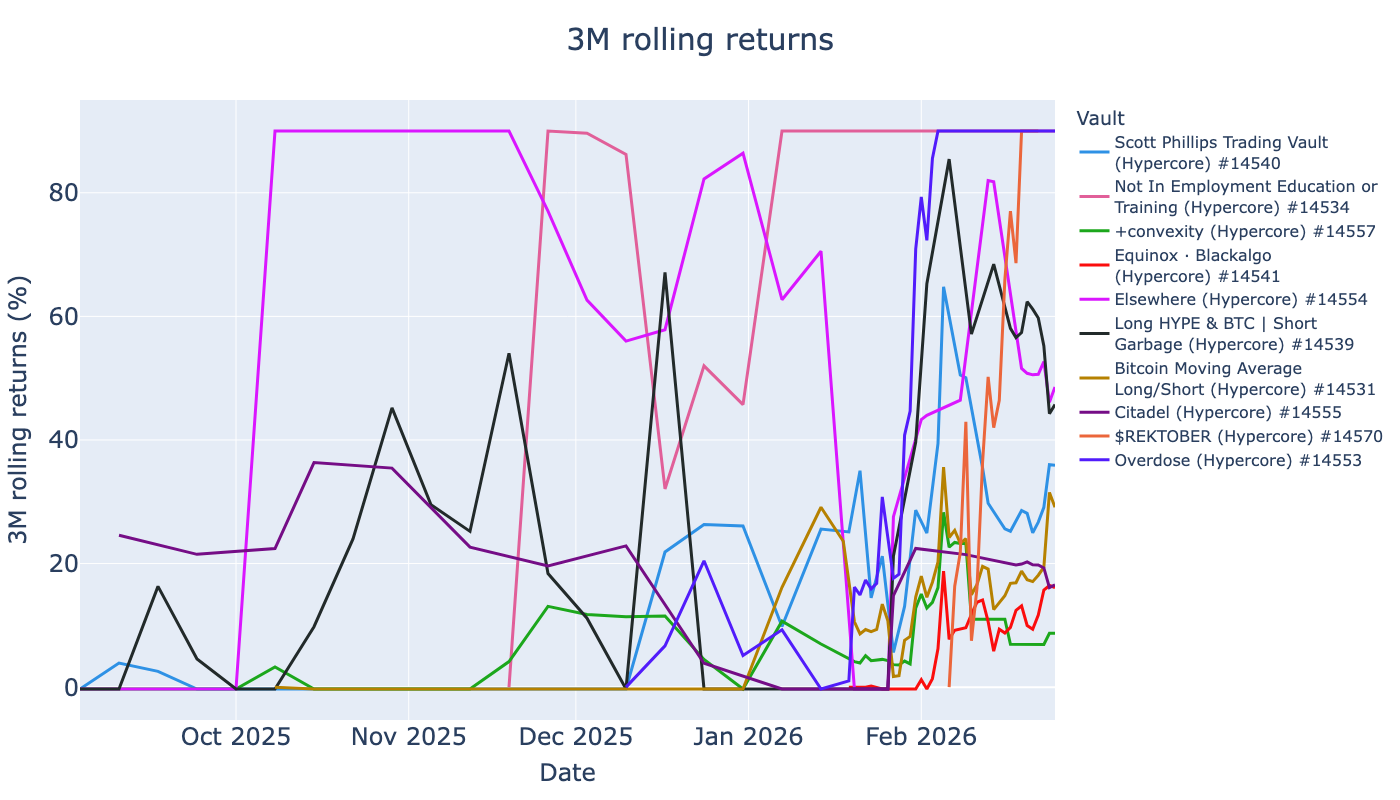

In [12]:
# display(lifetime_data_filtered_df.head(2))


# Need to remove HLP to make the chart readable
BLACKLISTED_ADDRESSES = {
    "0xdfc24b077bc1425ad1dea75bcb6f8158e10df303",  # HLP main
    "0x31ca8395cf837de08b24da3f660e77761dfb974b",  # HLP Strategy B
    "0x010461c14e146ac35fe42271bdc1134ee31c703a",  # HLP Strategy A
    "0x469f690213c467c39a23efacfd2816896009d7d8",  # HLP Strategy X
    "0xb0a55f13d22f66e6d495ac98113841b2326e9540",  # HLP Liquidator 2
    "0x2ed5c4484ea3ff8b57d5f2fb152a40d9f2b68308",  # HLP Liquidator 4
    "0x5e177e5e39c0f4e421f5865a6d8beed8d921cb70",  # HLP Liquidator 3
    "0x2e3d94f0562703b25c83308a05046ddaf9a8dd14",  # HLP Liquidator
    "0xa020235678b58e7e94c61ad2f350d476e637c062",  # Harvest 
}
lifetime_data_filtered_df = lifetime_data_filtered_df[~lifetime_data_filtered_df["address"].isin(BLACKLISTED_ADDRESSES)]

rolling_returns_df = calculate_rolling_returns(
    returns_df,
    filtered_vault_list_df=lifetime_data_filtered_df,
    clip_up=90, 
    clip_down=-0.30,
    history_length=history_length,
    rolling_period=rolling_period
)

fig = visualise_rolling_returns(
    rolling_returns_df,
    title=f"{label} rolling returns",
    yaxis_title=f"{label} rolling returns (%)",
)
fig.show()

### Best performing low volatile vaults

- Remove volatile vaults to focus on delta neutral vaults


Volatility min: 0.0000, max: 5.4455


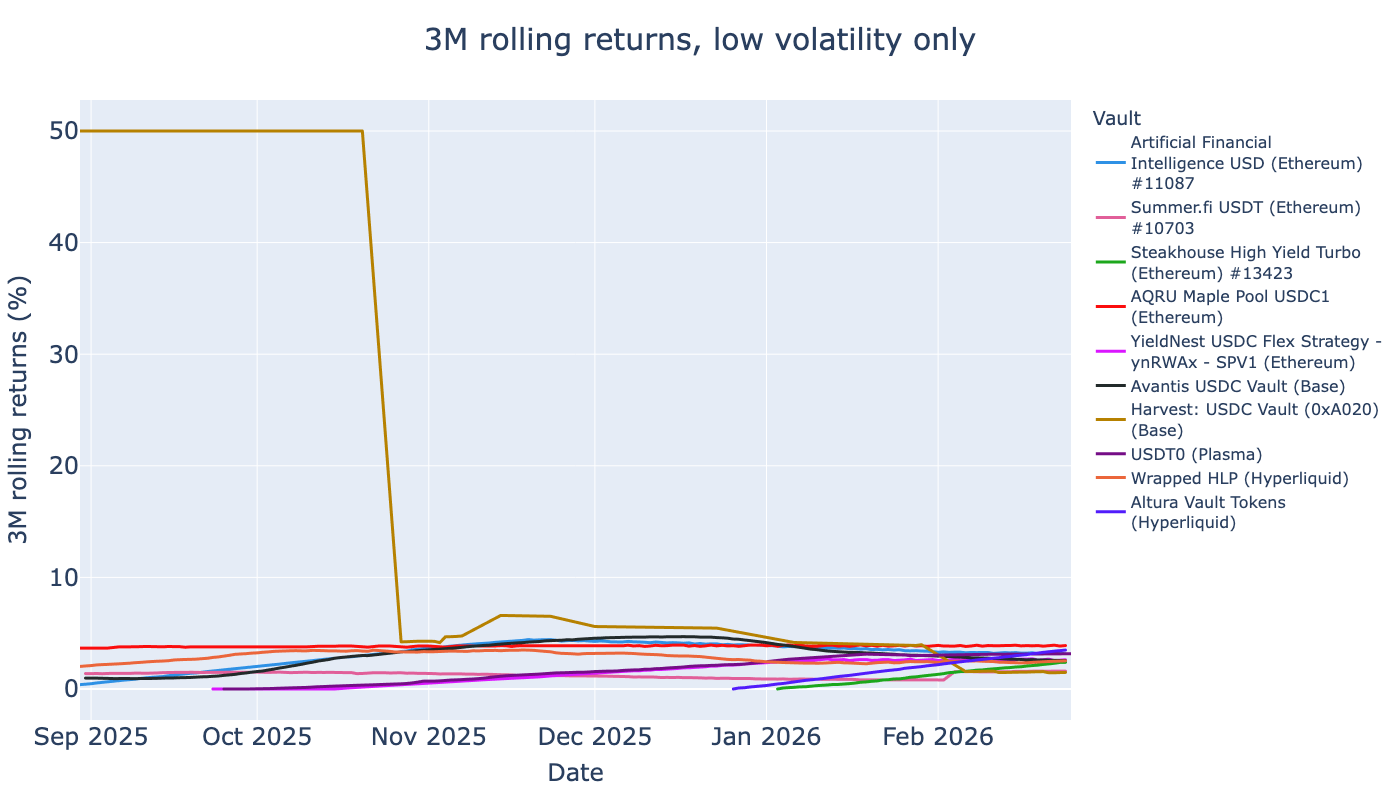

In [13]:
print(f"Volatility min: {lifetime_data_filtered_df['three_months_volatility'].min():.4f}, max: {lifetime_data_filtered_df['three_months_volatility'].max():.4f}")

non_volatile_df = lifetime_data_filtered_df[lifetime_data_filtered_df["three_months_volatility"] < 0.005]

non_volatile_df = non_volatile_df[~non_volatile_df["address"].str.lower().isin(BLACKLISTED_ADDRESSES)]


# display(non_volatile_df)

rolling_returns_df = calculate_rolling_returns(
    returns_df,
    filtered_vault_list_df=non_volatile_df,
    clip_up=50,  # Clip up to 700% returns
    clip_down=-0.30,
    history_length=history_length,
    rolling_period=rolling_period

)

fig = visualise_rolling_returns(
    rolling_returns_df,
    title=f"{label} rolling returns, low volatility only",
    yaxis_title=f"{label} rolling returns (%)",
)
fig.show()

### Returns correlation

- How uncorrelated the returns of the top vaults are
- We use special filtering criteria to create the list of top vaults to compare



For the correlation matrix, we choose the top 20 vaults by their 3M returns, with minimum TVL of 50,000 USD and then limiting to 2 vaults per protocol to have more variety.


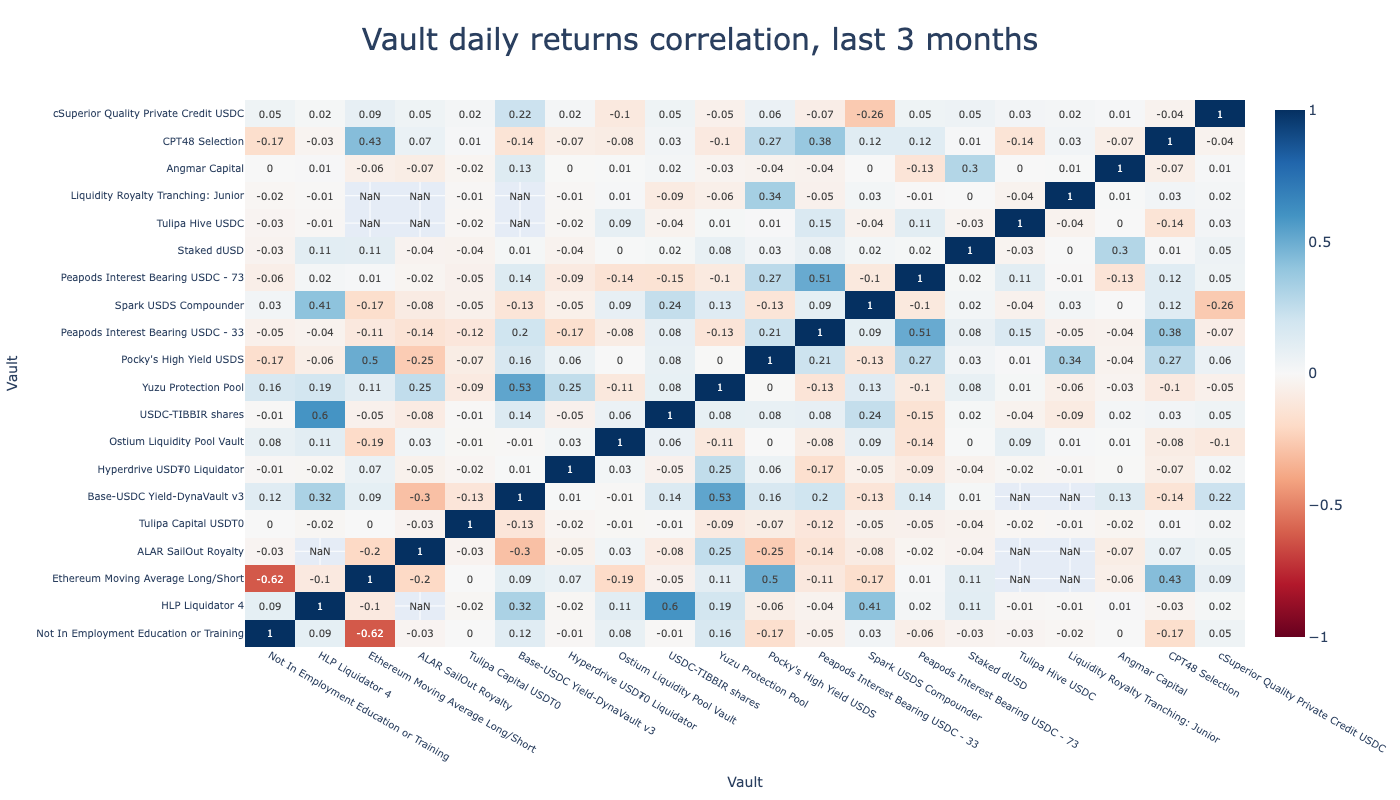

Selected vaults for correlation comparison:
|    | Vault                                                                                                                                                                                        | 3M return ann. (net / gross)   |   3M sharpe |   Age (years) | Chain                                                                     | Protocol                      | Denomination   | TVL USD (current / peak)   |
|---:|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-------------------------------|------------:|--------------:|:--------------------------------------------------------------------------|:------------------------------|:---------------|:---------------------------|
|  1 | [Not In Employment Education or Training](https://tradingstrategy.ai/trading-view/hyperliquid/vaults/not-in-employment-

In [14]:
from eth_defi.research.vault_correlation import choose_vaults_for_correlation_comparison, visualise_vault_returns_correlation

selected_lifetime_data_df = choose_vaults_for_correlation_comparison(
    lifetime_data_df,
    min_nav=50_000,
    per_protocol=2,
    max=20,
)


# display(returns_df.head())

last_ts = returns_df.index.max()
cut_off = last_ts - pd.Timedelta(days=90)
three_months_returns_df = returns_df.loc[returns_df.index > cut_off]

fig = visualise_vault_returns_correlation(
    selected_lifetime_data_df=selected_lifetime_data_df,
    returns_df=three_months_returns_df,
)
fig.update_xaxes(tickfont=dict(size=10), title_font=dict(size=14))
fig.update_yaxes(tickfont=dict(size=10), title_font=dict(size=14))
fig.update_coloraxes(colorbar=dict(tickfont=dict(size=10), title_font=dict(size=10)))

# Alternative: directly update the colorbar on the trace
fig.update_traces(
    colorbar=dict(
        tickfont=dict(size=14),
        title=dict(font=dict(size=14))
    )
)

fig.show()

# BLOG_POST_COLUMNS = [
#     "Vault", 
#     "1M return ann. (net / gross)", 
#     "3M return ann. (net / gross)", 
#     "Lifetime return ann. (net / gross)", 
#     "3M sharpe",     
#     "TVL USD (current / peak)", 
#     "Age (years)", 
#     "Denomination", 
#     "Chain", 
#     "Protocol",
# ]

human_df = format_lifetime_table(selected_lifetime_data_df, profit_presentation="net_only")
markdown_df = format_markdown_table(
    human_df, 
    ["Vault", "3M return ann. (net / gross)", "3M sharpe", "Age (years)",  "Chain", "Protocol",  "Denomination", "TVL USD (current / peak)"],
)
print("Selected vaults for correlation comparison:")

print(markdown_df.to_markdown(index=True, tablefmt="pipe", floatfmt=",.2f"))

### Best performing vaults by a chain

- Take 5 top vaults from each 
- TVL filter applied

In [15]:
nav_threshold = 100_000
event_threshold = 0

lifetime_data_filtered_df = lifetime_data_df[
    (lifetime_data_df["current_nav"] >= nav_threshold) 
]


# Get top 5 vaults by one_month_returns for each chain with ranking
def get_top_vaults_by_chain(df, metric_column="one_month_cagr", top_n=5):
    result_dfs = []

    df = df.reset_index()

    for chain in df["chain"].unique():
        chain_df = df[df["chain"] == chain].copy()

        # Sort by the metric in descending order
        chain_df = chain_df.sort_values(by=metric_column, ascending=False)

        # Take top N entries
        top_chain_df = chain_df.head(top_n).copy()

        result_dfs.append(top_chain_df)

    # Combine all chains
    combined_df = pd.concat(result_dfs, ignore_index=True)

    return combined_df


# Get top 5 vaults by one_month_cagr for each chain
top_vaults_by_chain_df = get_top_vaults_by_chain(lifetime_data_filtered_df, metric_column="one_month_cagr", top_n=3)

# BLOG_POST_COLUMNS = [
#     "Vault", 
#     "1M return ann. (net / gross)", 
#     "3M return ann. (net / gross)", 
#     "Lifetime return ann. (net / gross)", 
#     "3M sharpe",     
#     "TVL USD (current / peak)", 
#     "Age (years)", 
#     "Denomination", 
#     "Chain", 
#     "Protocol",
# ]

# For chain comparison, we order a bit differently
CHAIN_COMPARISON_COLUMNS = [
    "Chain",
    "Protocol",
    "Vault",
    "1M return ann. (net / gross)", 
    "3M return ann. (net / gross)",
    "Lifetime return ann. (net / gross)", 
    "TVL USD (current / peak)",
    "Age (years)",
    "Denomination",
]


top_vaults_by_chain_df = top_vaults_by_chain_df.sort_values(by=["chain", "one_month_cagr"], ascending=[True, False])
sorted_df = format_lifetime_table(top_vaults_by_chain_df, profit_presentation="net_only")
# display(top_vaults_by_chain_df)
markdown_df = format_markdown_table(sorted_df, BLOG_POST_COLUMNS, hide_index=False)

markdown_df = markdown_df[CHAIN_COMPARISON_COLUMNS]

print(markdown_df.to_markdown(index=False, tablefmt="pipe", floatfmt=",.2f"))

| Chain                                                                     | Protocol                      | Vault                                                                                                                                                                                           | 1M return ann. (net / gross)   | 3M return ann. (net / gross)   | Lifetime return ann. (net / gross)   | TVL USD (current / peak)   |   Age (years) | Denomination   |
|:--------------------------------------------------------------------------|:------------------------------|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-------------------------------|:-------------------------------|:-------------------------------------|:---------------------------|--------------:|:---------------|
| [Arbitrum](https://tradingstrategy.ai/trading-view/arbit

### Best-performing large vaults (min $2M TVL), list


In [16]:
nav_threshold = 2_000_000
event_threshold = 10

lifetime_data_filtered_df = lifetime_data_df[(lifetime_data_df["current_nav"] >= nav_threshold) & (lifetime_data_df["event_count"] >= event_threshold)]

positive_returns_df = lifetime_data_filtered_df[lifetime_data_filtered_df["lifetime_return"] > 0]
negative_returns_df = lifetime_data_filtered_df[lifetime_data_filtered_df["lifetime_return"] <= 0]

# print(f"All vaults sorted by lifetime returns and having currnet NAV > ${nav_threshold:,} USD")
# print(f"Vaults with positive returns {len(positive_returns_df):,} out of {len(lifetime_data_filtered_df)} total vaults")
#   print(f"Vaults with negative returns {len(negative_returns_df):,} out of {len(lifetime_data_filtered_df)} total vaults")

lifetime_data_filtered_df = lifetime_data_filtered_df.sort_values(by="one_month_cagr", ascending=False)

column_to_shift = "three_months_cagr"
new_order = [column_to_shift] + [col for col in lifetime_data_filtered_df.columns if col != column_to_shift]
lifetime_data_filtered_df = lifetime_data_filtered_df[new_order]

sorted_df = format_lifetime_table(lifetime_data_filtered_df.head(50), profit_presentation="net_only")
markdown_df = format_markdown_table(sorted_df, BLOG_POST_COLUMNS)
print(markdown_df.to_markdown(index=True, tablefmt="pipe", floatfmt=",.2f"))

|    | Vault                                                                                                                                                                                                                   | 1M return ann. (net / gross)   | 3M return ann. (net / gross)   | Lifetime return ann. (net / gross)   |   3M sharpe | TVL USD (current / peak)   |   Age (years) | Denomination   | Chain                                                                     | Protocol                      |
|---:|:------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-------------------------------|:-------------------------------|:-------------------------------------|------------:|:---------------------------|--------------:|:---------------|:--------------------------------------------------------------------------|:----

### Best-performing large vaults (min $2M TVL), chart 


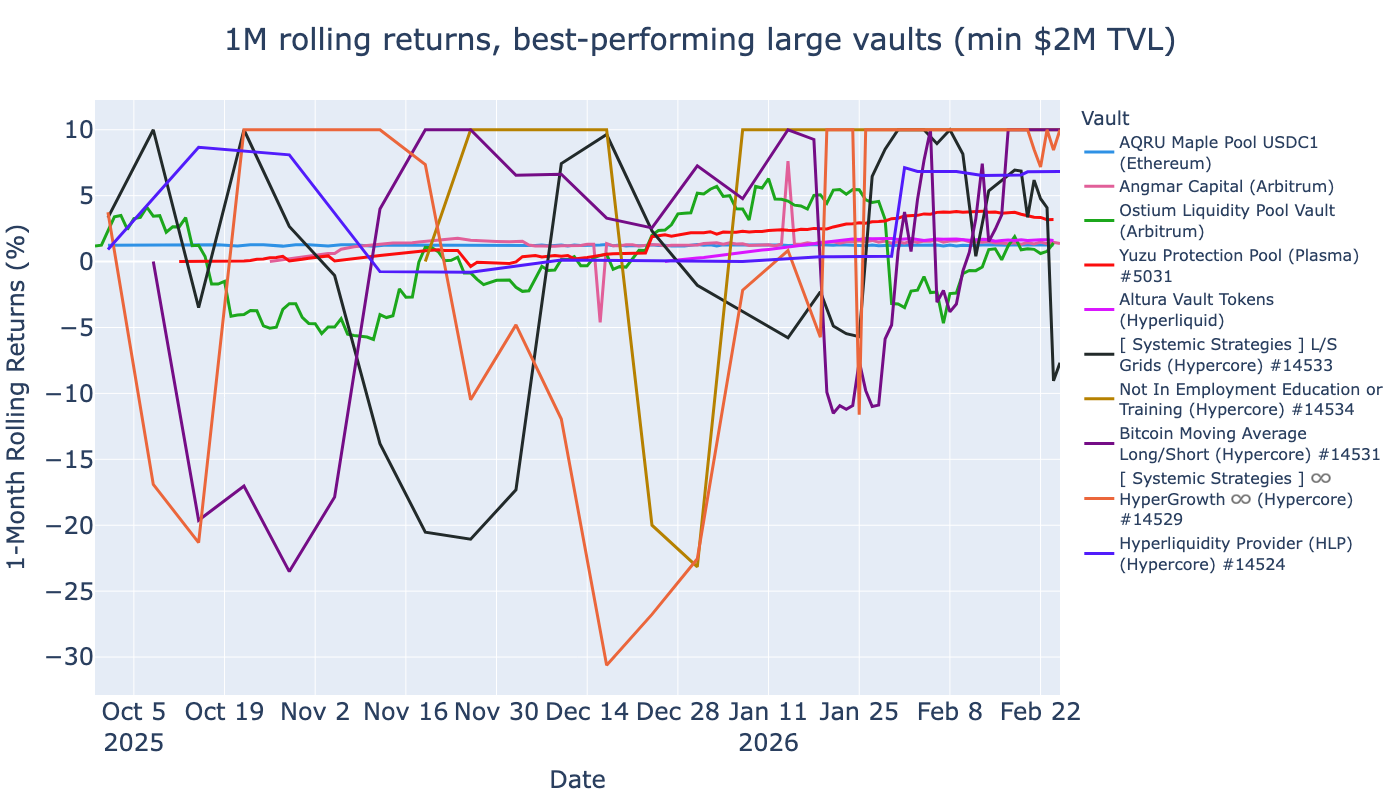

In [17]:
rolling_returns_df = calculate_rolling_returns(
    returns_df,
    filtered_vault_list_df=lifetime_data_filtered_df,
    clip_up=10,  # Clip up to 700% returns
)

# display(rolling_returns_df.head(3))
# display(rolling_returns_df.tail(3))

fig = visualise_rolling_returns(
    rolling_returns_df,
    title="1M rolling returns, best-performing large vaults (min $2M TVL)",
)
fig.show()

### Best-performing large vaults, non-volatile, chart

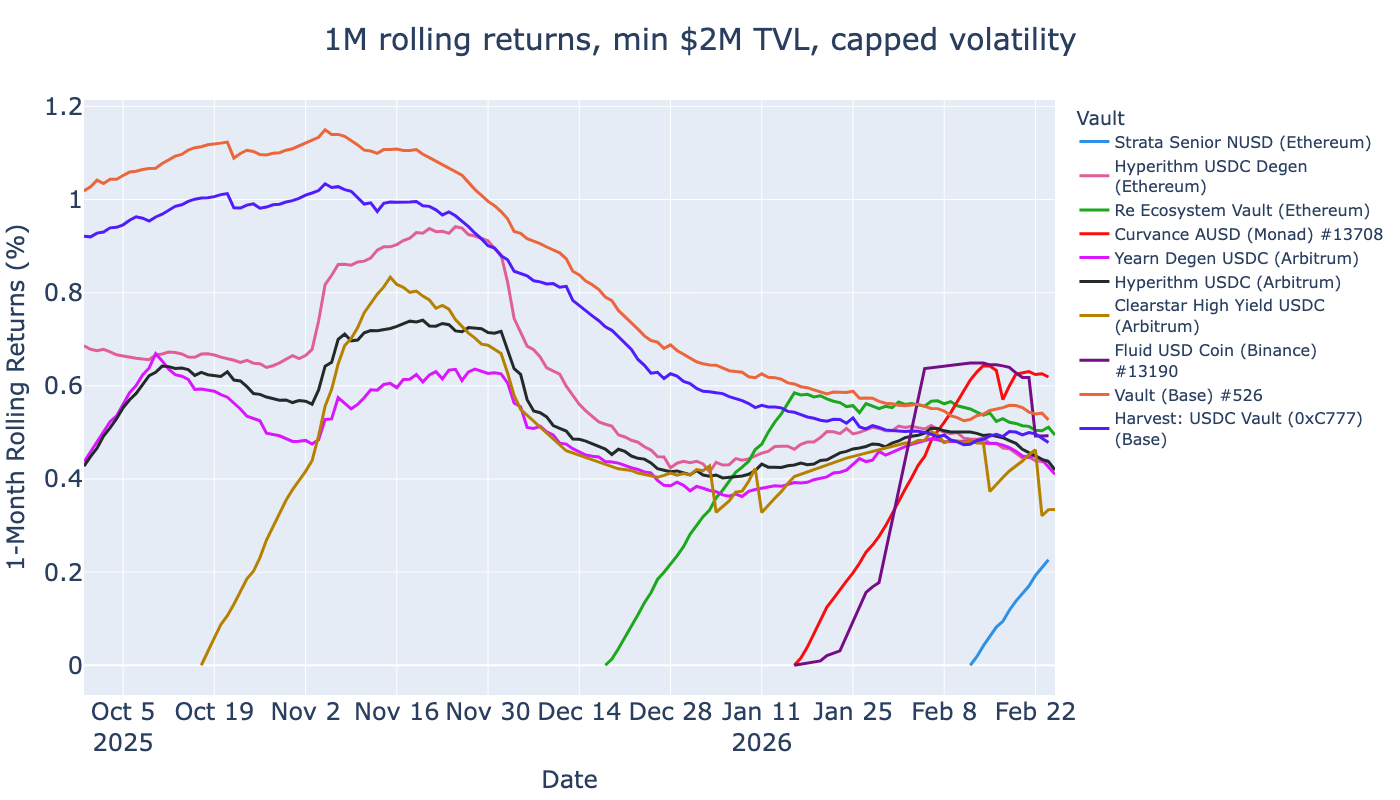

In [18]:
non_volatile_df = lifetime_data_filtered_df[lifetime_data_filtered_df["three_months_volatility"] < 0.001]

# display(non_volatile_df)

rolling_returns_df = calculate_rolling_returns(
    returns_df,
    filtered_vault_list_df=non_volatile_df,
    clip_up=33,  # Clip up to 700% returns
)

fig = visualise_rolling_returns(
    rolling_returns_df,
    title="1M rolling returns, min $2M TVL, capped volatility",
)
fig.show()

### Best performing new vaults

- Vaults less than two months old
- Have more than USD 15k in deposits
- Have more than 10 depositors

In [19]:
nav_threshold = 15_000
event_threshold = 10
age_threshold = 2 / 12  # Two months

lifetime_data_filtered_df = lifetime_data_df[
    (lifetime_data_df["current_nav"] >= nav_threshold) & 
    (lifetime_data_df["event_count"] >= event_threshold) & 
    (lifetime_data_df["years"] <= age_threshold) &
    (lifetime_data_df["address"].apply(lambda addr: not is_flagged_vault(addr))) 
]

positive_returns_df = lifetime_data_filtered_df[lifetime_data_filtered_df["lifetime_return"] > 0]
negative_returns_df = lifetime_data_filtered_df[lifetime_data_filtered_df["lifetime_return"] <= 0]

lifetime_data_filtered_df = lifetime_data_filtered_df.sort_values(by="one_month_cagr", ascending=False)

column_to_shift = "three_months_cagr"
new_order = [column_to_shift] + [col for col in lifetime_data_filtered_df.columns if col != column_to_shift]
lifetime_data_filtered_df = lifetime_data_filtered_df[new_order]

sorted_df = format_lifetime_table(lifetime_data_filtered_df.head(50), profit_presentation="net_only")
markdown_df = format_markdown_table(sorted_df, BLOG_POST_COLUMNS)
print(markdown_df.to_markdown(index=True, tablefmt="pipe", floatfmt=",.2f"))

|    | Vault                                                                                                                                                                            | 1M return ann. (net / gross)   | 3M return ann. (net / gross)   | Lifetime return ann. (net / gross)   |   3M sharpe | TVL USD (current / peak)   |   Age (years) | Denomination   | Chain                                                                     | Protocol                      |
|---:|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-------------------------------|:-------------------------------|:-------------------------------------|------------:|:---------------------------|--------------:|:---------------|:--------------------------------------------------------------------------|:------------------------------|
|  1 | [$REKTOBER](https://tradingstrategy.ai/trad